# Session 9


Feature Engineering (SMA EMA ...): Feature Engineering with SMA (Simple Moving Average)

 What It Does
- SMA = Average of last N values (window slides one step each day)
- Adds CONTEXT: "Is today's price high or low?"
- Shows TREND direction: Above average = uptrend, Below = downtrend
- Reduces NOISE: Smooths out random jumps


-------------------------------------
📝 ML Input-Output Approaches

1. Single Feature → Single Target
X = [Close]  →  y = [price_tomorrow]

2. Single Feature → Multiple Targets (Multi-Output)
 X = [Close]  →  y = [t+1, t+2, t+3]
 Each target has its own accuracy (t+1 easiest, t+3 hardest).

3. Multiple Features → Single Target
X = [Open, High, Low, Close]  →  y = [price_tomorrow]

4. Multiple Features → Multiple Targets
X = [Open, High, Low, Close]  →  y = [t+1, t+2, t+3]

5. Sequencing (Sliding Window)
Turn time into features:
  Raw: [100, 102, 105, 103, 108]
  Window=3: X[0]=[100,102,105]→y=103, X[1]=[102,105,103]→y=108

One source column (Close) → 2D → sklearn works ✅
Two source columns (Close+Open) → 3D → sklearn fails ❌ (need LSTM)

Target Rule
All targets must be the SAME type (e.g., all prices, different times).
❌ [price, temperature] — unrelated targets won't work! 


Feture Engineering VS Feature Extraction

Feature ENGINEERING: Create NEW columns from raw data

  → SMA, log, returns, ratios, day_of_week
  → You use DOMAIN KNOWLEDGE to create them
  → Original features stay, new ones added

Feature EXTRACTION: Transform data into NEW space

  → PCA, t-SNE, Autoencoders
  → Algorithm combines features mathematically
  → Original features replaced by new ones
  
----------------------------------

Feature Scaling (X vs. y):

Scale X (Features):

Why: Many algorithms (distance-based, gradient descent, regularization) are sensitive to feature scales. Unscaled features can lead to bias, slow convergence, or dominance by high-value features.

Common Methods: StandardScaler (mean=0, std=1), MinMaxScaler (0 to 1).

Do NOT Scale y (Target/Label) - Typically:
Why: The original scale of y is usually meaningful for interpretation and prediction (e.g., predicting prices in dollars). Scaling y complicates interpretation and requires inverse transformation.

Exceptions: Rare, advanced models or highly skewed y values might benefit from transformations (like log), but this is distinct from standard scaling.

----------------------------------


Polynomial vs. Multiple Regression -
1. Multiple Regression:

Predicts target (y) using two or more independent variables (X1, X2, …).

Assumes a linear relationship between each X and y.

Equation form: y = b0 + b1*X1 + b2*X2 + ... + bn*Xn

Example: Predicting house price (y) based on square footage (X1) and number of bedrooms (X2).

2. Polynomial Regression:

**Predicts target (y) using one or more independent variables (X) where the relationship is non-linear. **

Fits a curve to the data by adding polynomial terms (X^2, X^3, etc.) as new features.

Equation form (for one variable): y = b0 + b1*X + b2*X^2 + b3*X^3 + ...

Example: Predicting plant growth (y) based on sunlight exposure (X), where growth increases up to a point and then plateaus or decreases (a curve). You’d add X^2 as a feature.

Key Difference: Multiple Regression uses multiple linear predictors. Polynomial Regression models curved relationships, often by creating new, non-linear features from existing ones.

--------------------------------


ML Pipeline:

Concept: An automated assembly line for data, connecting all steps from raw data to final prediction.

Purpose: Ensures consistency, reproducibility, and efficiency in ML workflows. Automates:

Data Ingestion & Cleaning

Feature Engineering (Encoding, Scaling)

Model Training

Inference (Prediction)

Benefit: Prevents “Training-Serving Skew” by ensuring identical data processing logic for training and prediction.

------------------------

📝 Three Ways to Get Better Features

1. Domain Expert (Manual)

 
You create features based on knowledge of the field.


Finance: SMA, EMA, volatility | Medical: BMI, ratios | Real Estate: price_per_sqm

2. Mathematical Tools (Unsupervised)

Algorithms that transform data without labels.


PCA, SVD, t-SNE, UMAP, LLE, Kernel PCA

3. Models That Select/Create Features (Supervised)
   
Lasso → zeros out useless features

Random Forest / XGBoost → feature importance ranking

Neural Networks → CNN auto-extracts edges, Autoencoder compresses data

--------------------
Pickle - Try:  - df.select_dtypes(include=[]) - ColumnsTransformer

## Implement feature engineering on BTC

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
# Work with BTC - implemnting above materials on the btc data
df = pd.read_csv('BTC-USD.csv')
#df.index = df["Date"]
#df.drop(columns=["Date"])
#df[0]
df['Close'].isna().sum()

0

In [111]:
# Feature Extraction (WRONG) - Feture Engineering (TRUE)
df["Return"] = df["Close"] - df["Open"]
df

,Date,Open,High,Low,Close,Adj Close,Volume,Return
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900,5.602997
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,16.824005
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,12.278015
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-3.125000
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.937012
...,...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-978.398438
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,793.574219
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-1292.667969
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396,567.503906


In [112]:
# another way for feature engineering: sma
df["SMA_30"] = df["Close"].rolling(30).mean()

#2014-10-07
#df.dropna(subset=['SMA_30'],inplace=True)
df
# So in model we use X = df[["Close", "SMA_30"]] this as X :))

,Date,Open,High,Low,Close,Adj Close,Volume,Return,SMA_30
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900,5.602997,NaN
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,16.824005,NaN
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,12.278015,NaN
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-3.125000,NaN
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.937012,NaN
...,...,...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-978.398438,66774.136068
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,793.574219,66551.088802
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-1292.667969,66309.156901
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396,567.503906,66059.903125


In [115]:
# Feature Engineering
df["LogReturn"] = np.log(df["Return"])
df

#log is not for feature scaling 

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Date,Open,High,Low,Close,Adj Close,Volume,Return,SMA_30,LogReturn
0,2014-10-07,330.584015,339.247009,320.481995,336.187012,336.187012,49199900,5.602997,NaN,1.723302
1,2014-10-08,336.115997,354.364014,327.187988,352.940002,352.940002,54736300,16.824005,NaN,2.822807
2,2014-10-09,352.747986,382.726013,347.687012,365.026001,365.026001,83641104,12.278015,NaN,2.507810
3,2014-10-10,364.687012,375.066986,352.963013,361.562012,361.562012,43665700,-3.125000,NaN,NaN
4,2014-10-11,361.362000,367.191010,355.950989,362.299011,362.299011,13345200,0.937012,NaN,-0.065059
...,...,...,...,...,...,...,...,...,...,...
3550,2024-06-26,61789.675781,62434.136719,60695.187500,60811.277344,60811.277344,22506003064,-978.398438,66774.136068,NaN
3551,2024-06-27,60811.226562,62293.863281,60585.332031,61604.800781,61604.800781,21231745045,793.574219,66551.088802,6.676547
3552,2024-06-28,61612.804688,62126.097656,59985.402344,60320.136719,60320.136719,24952866877,-1292.667969,66309.156901,NaN
3553,2024-06-29,60319.875000,61097.621094,60300.964844,60887.378906,60887.378906,12652903396,567.503906,66059.903125,6.341248


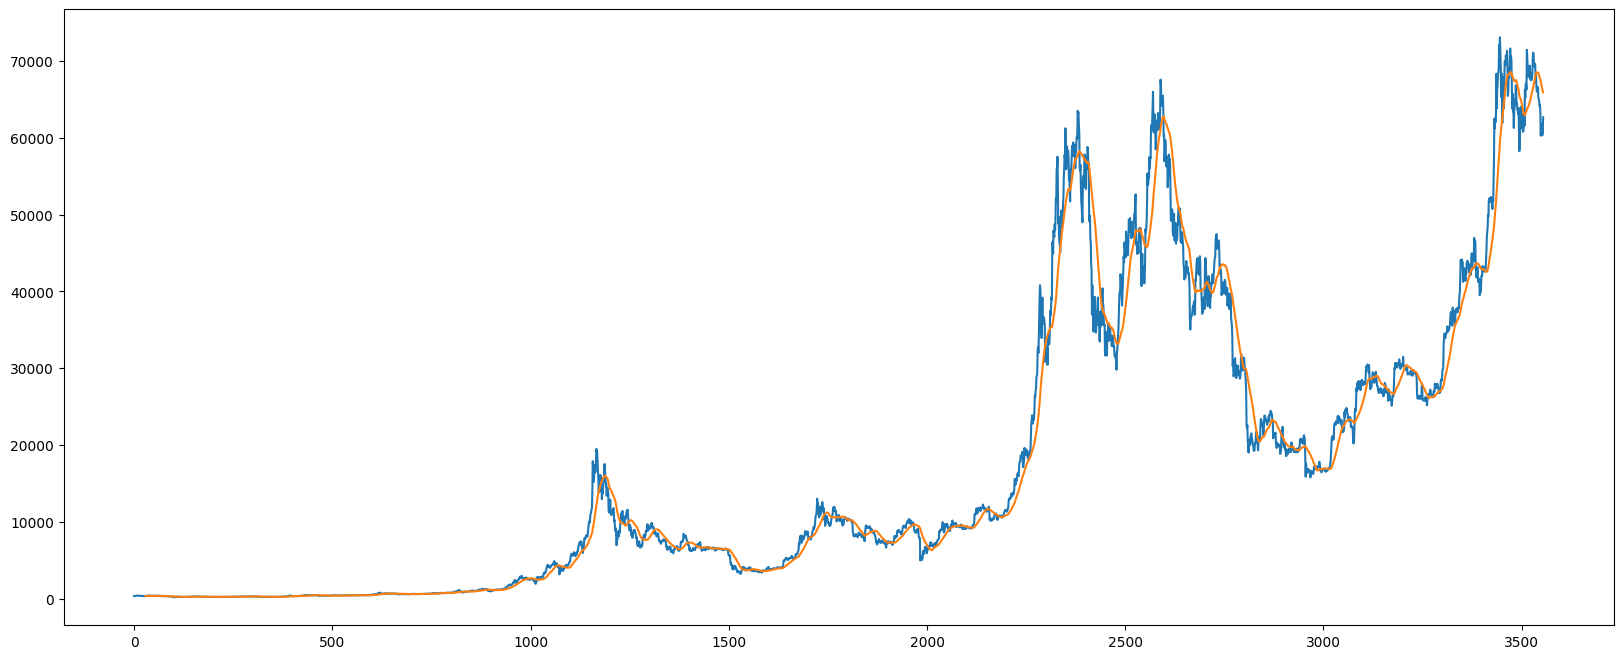

In [114]:
plt.figure(figsize=(20,8))
plt.plot(df["Close"])
plt.plot(df["SMA_30"])

In [116]:
# Example when we have multiple target
df["CloseTomorrow_1"] = df["Close"].shift(-1)
df["CloseTomorrow_2"] = df["Close"].shift(-2)
df["CloseTomorrow_3"] = df["Close"].shift(-3)

#SO your X an y can be like:
X = df[["Open", "High", "Low", "Close"]]
y = df[["CloseTomorrow_1", "CloseTomorrow_2", "CloseTomorrow_3"]]

print(X)
print(y)



              Open          High           Low         Close
0       330.584015    339.247009    320.481995    336.187012
1       336.115997    354.364014    327.187988    352.940002
2       352.747986    382.726013    347.687012    365.026001
3       364.687012    375.066986    352.963013    361.562012
4       361.362000    367.191010    355.950989    362.299011
...            ...           ...           ...           ...
3550  61789.675781  62434.136719  60695.187500  60811.277344
3551  60811.226562  62293.863281  60585.332031  61604.800781
3552  61612.804688  62126.097656  59985.402344  60320.136719
3553  60319.875000  61097.621094  60300.964844  60887.378906
3554  60888.445312  62892.828125  60632.949219  62678.292969

[3555 rows x 4 columns]
      CloseTomorrow_1  CloseTomorrow_2  CloseTomorrow_3
0          352.940002       365.026001       361.562012
1          365.026001       361.562012       362.299011
2          361.562012       362.299011       378.549011
3          362.2990

In [117]:
# Sequencing:
sequence_len = 7
n_samples, n_features = df.shape

X=[]
y=[]
for i in range (0,n_samples - sequence_len):
    batch = df.iloc[i:i+ sequence_len]
    #print(batch.shape)
    X.append(batch["Close"].tolist())
    y.append(df["Close"].iloc[i + sequence_len])

    print(batch['Close'].tolist(),df["Close"].iloc[i + sequence_len])

#Now X,y


[336.18701171875, 352.94000244140625, 365.0260009765625, 361.56201171875, 362.2990112304688, 378.5490112304688, 390.41400146484375] 400.8699951171875
[352.94000244140625, 365.0260009765625, 361.56201171875, 362.2990112304688, 378.5490112304688, 390.41400146484375, 400.8699951171875] 394.7730102539063
[365.0260009765625, 361.56201171875, 362.2990112304688, 378.5490112304688, 390.41400146484375, 400.8699951171875, 394.7730102539063] 382.5559997558594
[361.56201171875, 362.2990112304688, 378.5490112304688, 390.41400146484375, 400.8699951171875, 394.7730102539063, 382.5559997558594] 383.7579956054688
[362.2990112304688, 378.5490112304688, 390.41400146484375, 400.8699951171875, 394.7730102539063, 382.5559997558594, 383.7579956054688] 391.4419860839844
[378.5490112304688, 390.41400146484375, 400.8699951171875, 394.7730102539063, 382.5559997558594, 383.7579956054688, 391.4419860839844] 389.5459899902344
[390.41400146484375, 400.8699951171875, 394.7730102539063, 382.5559997558594, 383.75799560

In [47]:
#multiple target in sequencing
X = []
y=[]
sequence_x = 7
sequence_y = 3
n_sample, n_feature = df.shape

for i in  range (0,n_sample - sequence_x-sequence_y+1):
    batch = df.iloc[i:i+sequence_x]
    X.append(batch["Close"])
    y.append(df["Close"].iloc[i + sequence_x : i + sequence_x + sequence_y])
X
y

[7    400.869995
 8    394.773010
 9    382.556000
 Name: Close, dtype: float64,
 8     394.773010
 9     382.556000
 10    383.757996
 Name: Close, dtype: float64,
 9     382.556000
 10    383.757996
 11    391.441986
 Name: Close, dtype: float64,
 10    383.757996
 11    391.441986
 12    389.545990
 Name: Close, dtype: float64,
 11    391.441986
 12    389.545990
 13    382.845001
 Name: Close, dtype: float64,
 12    389.545990
 13    382.845001
 14    386.475006
 Name: Close, dtype: float64,
 13    382.845001
 14    386.475006
 15    383.157990
 Name: Close, dtype: float64,
 14    386.475006
 15    383.157990
 16    358.416992
 Name: Close, dtype: float64,
 15    383.157990
 16    358.416992
 17    358.345001
 Name: Close, dtype: float64,
 16    358.416992
 17    358.345001
 18    347.270996
 Name: Close, dtype: float64,
 17    358.345001
 18    347.270996
 19    354.704010
 Name: Close, dtype: float64,
 18    347.270996
 19    354.704010
 20    352.989014
 Name: Close, dtype: floa

## Polynomial

In [152]:
#Polynomial 
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, OneHotEncoder


X = np.array([[3,2]]) #two features

y= [3]
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
print(X_poly)

#X_poly are new X for linearregression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly,y)
#print("Intercept (b):", model.intercept_)
#print("Coefficients:", model.coef_)

[[1. 3. 2. 9. 6. 4.]]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [154]:
#Number of polynomial features = C(n + d, d) 

#n = number of original features
#d = polynomial degree
#C = combination
from math import comb
comb(4,2) #[[1. 3. 2. 9. 6. 4.]] here we have 6 :)

6

## Pipeline 

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

Train_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

Train_pipeline

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


ColumnTransformer = "Apply different preprocessing to each column type"

Numeric columns → Scale

Category columns → Encode

Text columns → TF-IDF

All in one step!

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
df = pd.read_csv("data.csv")
df

,day,amount,count,result
0,sun,1000,2,0
1,mon,2000,1,0
2,tue,1500,2,1
3,wed,1800,3,1


In [101]:
X = df[['day','amount','count']]
y = df['result']

In [102]:
#build columntransformer
pre_process = ColumnTransformer([
    ("scaler", StandardScaler(), ["amount", "count"]),
    ("encode", TfidfVectorizer(), "day")
],sparse_threshold=0)

In [103]:
train_pipeline = Pipeline([
    ('pre_processing', pre_process),
    ('cls',KNeighborsClassifier(n_neighbors=1))
    
])
train_pipeline

,steps,"[('pre_processing', ...), ('cls', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
#WRONG PEPLINE

train_pipeline = Pipeline([
    ("scaler", StandardScaler(), ["amount", "count"]),
    ("encode", TfidfVectorizer(), "day"),
    ('cls',KNeighborsClassifier(n_neighbors=1))
    
])
train_pipeline

,steps,"[('scaler', ...), ('encode', ...), ...]"
,transform_input,None
,memory,None
,verbose,False


In [104]:
train_pipeline.fit(X,y)
X_new = pd.DataFrame([["mon", 1900, 1]], columns=['day', 'amount', 'count'])
print(train_pipeline.predict(X_new))

train_pipeline.predict(X)


[0]


array([0, 0, 1, 1], dtype=int64)

In [ ]:
# If columns are a lot you have use sth can split datas into text and number
#select_dtype
text_columns = df.select_dtypes(include=["object", "string"])
numbers_columns = df.select_dtypes(include=["number","int"])

pre_process = ColumnTransformer([
    ("scaler", StandardScaler(), numbers_columns),
    ("encode", TfidfVectorizer(),text_columns )
],sparse_threshold=0)

print(text_columns)

numbers_columns

Pickle — Save & Load Models :

Pickling is the process of converting a Python object (such as a list, dictionary, or class object) into a byte stream so that it can be saved to a file or transmitted over a network.

In [86]:
import pickle

data = {'name': 'Jenny', 'age': 25}  
pickle.dump(data, open('data.pkl','wb'))
load = pickle.load(open('data.pkl','rb'))
load

#Explanation:

# import pickle: Imports the pickle module to handle serialization.
# data = {...}: Creates a Python object to be saved.
# pickle.dump(data, open('data.pkl', 'wb')): Serializes (pickles) the object and writes it to data.pkl.
# 'wb' means write in binary mode.
# loaded = pickle.load(open('data.pkl', 'rb')): Reads the file and deserializes (unpickles) it back into a Python object.
# 'rb' means read in binary mode.

{'name': 'Jenny', 'age': 25}

In [87]:
https://www.geeksforgeeks.org/python/understanding-python-pickling-example/

SyntaxError: invalid syntax (262465335.py, line 1)

In [88]:
data = {'name': 'Jenny', 'age': 25}  

with open('data2','wb') as file:
    pickle.dump(data,file)
    
with open('data2','rb') as file:
    see=pickle.load(file)

see

{'name': 'Jenny', 'age': 25}

In [89]:
import pickle

Leo = {'key': 'Leo', 'name': 'Leo Johnson', 'age': 21, 'pay': 40000}
Harry = {'key': 'Harry', 'name': 'Harry Jenner', 'age': 50, 'pay': 50000}

db = {}
db['Leo'] = Leo
db['Harry'] = Harry

with open('examplePickle', 'wb') as dbfile:
    pickle.dump(db, dbfile)

with open('examplePickle', 'rb') as dbfile:
    try:
        while True:
            db = pickle.load(dbfile)
            print(db)
    except EOFError:
        pass



{'Leo': {'key': 'Leo', 'name': 'Leo Johnson', 'age': 21, 'pay': 40000}, 'Harry': {'key': 'Harry', 'name': 'Harry Jenner', 'age': 50, 'pay': 50000}}


yo can use With or not:

with open()  → Auto-close ✅ Always use this

open()       → Must close manually ⚠️ Avoid

In [90]:
# sooo:
X = df[["day","amount", "count"]]
y = df["result"]

text_columns = df.select_dtypes(include=["object", "string"])
numbers_columns = df.select_dtypes(include=["number", "int", "float"])


pre_process = ColumnTransformer([
    ("scaler", StandardScaler(), numbers_columns),
    ("encode", TfidfVectorizer(), text_columns)
])

train_pipeline = Pipeline([
    ("pre_process", pre_process),
    ("clf", KNeighborsClassifier())
])
#save
with open('pipeline.pkl','wb') as file:
    pickle.dump(train_pipeline,file)

#read
with open ('pipeline','rb') as file:
    pipeline=pickle.load(file)

pipeline

,steps,"[('pre_process', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [91]:
print("Type:", type(pipeline))
print("Pipeline steps:", pipeline.named_steps)

Type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: {'pre_process': ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                    amount  count  result
0    1000      2       0
1    2000      1       0
2    1500      2       1
3    1800      3       1),
                                ('encode', TfidfVectorizer(),
                                    day
0  sun
1  mon
2  tue
3  wed)]), 'clf': KNeighborsClassifier()}
